In [1]:
# !pip install playsound # chỉ có âm thanh ko có video 
# !pip install moviepy # có âm thanh đi kèm video
# !pip install moviepy
# !pip uninstall -y opencv-python-headless opencv-contrib-python-headless
# !pip install -U opencv-python

In [2]:
# import sys
# print(sys.executable)
import sys
print(sys.executable)
import cv2
#!{sys.executable} -m pip install moviepy
import time
import os

C:\Users\Microsoft\miniconda3\envs\jupyter\python.exe


In [3]:
# ===== Cấu hình video =====
video_path = "20251003133754215.mp4"
if not os.path.exists(video_path):
    raise FileNotFoundError(f"File not found: {video_path}")

# ===== Hàm format thời gian =====
def format_time(seconds):
    m = int(seconds // 60)
    s = int(seconds % 60)
    return f"{m:02d}:{s:02d}"

# ===== Khởi tạo video =====
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise IOError("Cannot open video file")

In [4]:
# Đọc video từ file
my_video = cv2.VideoCapture("20251003133754215.mp4")
fps_original = my_video.get(cv2.CAP_PROP_FPS)
frame_count = int(my_video.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frame_count / fps_original
frame_duration = 1 / fps_original

In [5]:
# Ghi text trên hình ảnh hay Cấu hình font để ghi text
# ===== Cấu hình hiển thị =====
font = cv2.FONT_HERSHEY_SIMPLEX
font_color = (255, 255, 255)
font_scale = 1
font_thickness = 2
playback_speed = 1.0
paused = False

In [6]:
cv2.namedWindow('Video Player', cv2.WINDOW_NORMAL)

In [7]:
# ===== Vòng lặp phát video =====
while True:
    # Kiểm tra cửa sổ còn mở
    if cv2.getWindowProperty('Video Player', cv2.WND_PROP_VISIBLE) < 1:
        break

    if not paused:
        ret, frame = cap.read()
        if not ret:
            # Loop video từ đầu nếu muốn
            cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
            continue

        # Thời gian hiện tại
        current_frame = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
        current_time = current_frame / fps_original

        # Hiển thị FPS và thời gian
        cv2.putText(frame, f"FPS: {fps_original:.2f}", (10, 30),
                    font, font_scale, font_color, font_thickness)
        cv2.putText(frame, f"Time: {format_time(current_time)}/{format_time(duration)}",
                    (10, 70), font, font_scale, font_color, font_thickness)
        
        # Hiển thị frame
        cv2.imshow('Video Player', frame)

    # Delay theo tốc độ phát
    key = cv2.waitKey(int(frame_duration * 1000 / playback_speed)) & 0xFF

    # ===== Phím điều khiển =====
    if key == ord('q'):          # Q → thoát
        break
    elif key == 32:               # Space → pause/play
        paused = not paused
    elif key == ord('s'):         # S → snapshot
        ret, snap = cap.read()
        if ret:
            snap_name = f"snapshot_{int(time.time())}.png"
            cv2.imwrite(snap_name, snap)
            print(f"Saved snapshot: {snap_name}")
    elif key == 81:               # ← → tua lùi 5s
        cur_frame = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
        cap.set(cv2.CAP_PROP_POS_FRAMES, max(cur_frame - int(fps_original*5), 0))
    elif key == 83:               # → → tua nhanh 5s
        cur_frame = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
        cap.set(cv2.CAP_PROP_POS_FRAMES, min(cur_frame + int(fps_original*5), frame_count-1))
    elif key == 82:               # ↑ → tăng tốc 0.25x
        playback_speed = min(playback_speed + 0.25, 3.0)
    elif key == 84:               # ↓ → giảm tốc 0.25x
        playback_speed = max(playback_speed - 0.25, 0.25)

In [8]:
# Hủy bỏ Player, Giải phóng tài nguyên
my_video.release()
cv2.destroyAllWindows()
start_time = time.time()
ret, frame = my_video.read()

In [9]:
# BÀI HỌC TIẾP THEO
 #FPS(Frame Per Second): dịch là "khung hình trên giây".
 # - Nó đo lường tốc độ mà hình ảnh thay đổi trong một trò chơi hoặc ứng dụng đa phương tiện.
 # - FPS được đo bằng số lượng hình ảnh xuất hiện trong mỗi giây.


# Tham khảo bảng này cho Project 21
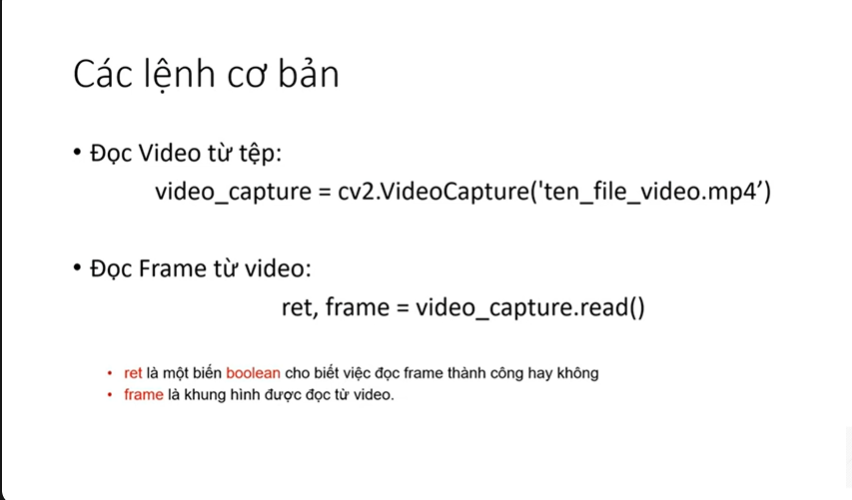